## Importing Libraries

In [201]:
import pandas as pd
import datetime as dt
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_probability_alive_matrix, plot_frequency_recency_matrix
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases, plot_period_transactions,plot_history_alive
from sklearn.preprocessing import MinMaxScaler

In [148]:
df=pd.read_excel('onlineretail.xlsx',sheet_name='Year 2010-2011')
df_copy = df.copy()
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [75]:
#use function for checking dataframe 
def check_df(dataframe):
    print('Shape of the dataframe:')
    print(dataframe.shape,'\n')
    print('Columns of the dataframe')
    print(dataframe.columns,'\n')
    print('Datatype of the dataframe:')
    print(dataframe.dtypes,'\n')
    print('First 5 rows of the dataframe:')
    print(dataframe.head(),'\n')
    print('Last 5 five rows of the dataframe:')
    print(dataframe.tail(),'\n')
    print('Description of the data in the dataframe:')
    print(dataframe.describe(),'\n')
check_df(df)


Shape of the dataframe:
(541910, 8) 

Columns of the dataframe
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object') 

Datatype of the dataframe:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object 

First 5 rows of the dataframe:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 

### Check for null values

In [77]:
#checking null values using isnull
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [78]:
#drop the rows containing null values
df.dropna(inplace=True)
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

### Outliers Detection 

In [80]:
# creating function outlier_thresholds() for outlier detection
def outlier_thresholds(dataframe,variable):
    quartile_1 = dataframe[variable].quantile(0.01)    #calculate lower range of data
    quartile_3 = dataframe[variable].quantile(0.99)    # calculate upper range of data
    interquantile_range=quartile_3 - quartile_1        # IQR is used to detect outliers
    up_limit = quartile_3 +1.5*interquantile_range     #any data above this threshold is considered an outlier
    low_limit = quartile_1 -1.5*interquantile_range    #any data below this threshold is considered an outlier
    return up_limit,low_limit 

# The above function returns the lower and upper limits for detecting outliers.
# Now we replace  outliers with thresholds using function
def replace_with_thresholds(dataframe,variable):
    up_limit,low_limit = outlier_thresholds(dataframe,variable) 
    dataframe.loc[(dataframe[variable] <low_limit),variable]=low_limit
    dataframe.loc[(dataframe[variable] >up_limit),variable]=up_limit 
    
    

In [81]:
df_uk=df[df['Country']=='United Kingdom']
df_uk

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


In [82]:
df_uk=df_uk[df_uk['Invoice'].apply(lambda x : 'C' not in str(x))]  # using lambda function to access invoice

In [83]:
df_uk = df_uk[df_uk['Price']>0]
df_uk

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


In [84]:
replace_with_thresholds(df_uk,'Price')
replace_with_thresholds(df_uk,'Quantity')
df_uk

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8.0,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


In [85]:
df_uk.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [86]:
df_uk['Total Price'] = df_uk['Quantity']*df_uk['Price']

In [87]:
df_uk[df_uk['Invoice']==536365]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50


In [88]:
df_uk['InvoiceDate'].max()

Timestamp('2011-12-09 12:49:00')

In [89]:
df.head

<bound method NDFrame.head of        Invoice StockCode                          Description  Quantity  \
0       536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       536365     71053                  WHITE METAL LANTERN         6   
2       536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...        ...       ...                                  ...       ...   
541905  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
541909  581587      POST                              POSTAGE         1   

               InvoiceDate  Price  Customer ID         Country  
0   

In [90]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [91]:
today_date = dt.datetime(2011,12,11)

In [92]:
df_uk=df_uk.groupby('Customer ID').agg({
    'Total Price' :'sum',
    'InvoiceDate':[lambda date : (date.max()-date.min()).days,lambda date : (today_date - date.min()).days],
    'Invoice' : lambda inv : inv.nunique()})
df_uk

Total Price InvoiceDate             Invoice
                    sum  <lambda_0> <lambda_1> <lambda>
Customer ID                                            
12346.0          258.44           0        326        1
12747.0         4196.01         366        370       11
12748.0        32303.91         372        374      209
12749.0         4072.44         209        214        5
12820.0          942.34         323        327        4
...                 ...         ...        ...      ...
18280.0          180.60           0        278        1
18281.0           80.82           0        181        1
18282.0          178.05         118        127        2
18283.0         2094.88         333        338       16
18287.0         1837.28         158        202        3

[3920 rows x 4 columns]

In [93]:
df_uk.columns.droplevel(0)

Index(['sum', '<lambda_0>', '<lambda_1>', '<lambda>'], dtype='object')

##### 1) frequency: The number of transactions made by each customer.
##### 2) recency: The time since the customer's last purchase.
##### 3) T: The total time the customer has been observed (the time from the first purchase to the present).

In [95]:
df_uk.columns =['Monetary','Recency','T','Frequency']
df_uk

,Monetary,Recency,T,Frequency
Customer ID,,,,
12346.0,258.44,0,326,1
12747.0,4196.01,366,370,11
12748.0,32303.91,372,374,209
12749.0,4072.44,209,214,5
12820.0,942.34,323,327,4
...,...,...,...,...
18280.0,180.60,0,278,1
18281.0,80.82,0,181,1
18282.0,178.05,118,127,2


In [96]:
df_uk['Monetary']=df_uk['Monetary']/df_uk['Frequency']
df_uk

,Monetary,Recency,T,Frequency
Customer ID,,,,
12346.0,258.440000,0,326,1
12747.0,381.455455,366,370,11
12748.0,154.564163,372,374,209
12749.0,814.488000,209,214,5
12820.0,235.585000,323,327,4
...,...,...,...,...
18280.0,180.600000,0,278,1
18281.0,80.820000,0,181,1
18282.0,89.025000,118,127,2


In [97]:
df_uk=df_uk[df_uk['Frequency']>1]
df_uk

,Monetary,Recency,T,Frequency
Customer ID,,,,
12747.0,381.455455,366,370,11
12748.0,154.564163,372,374,209
12749.0,814.488000,209,214,5
12820.0,235.585000,323,327,4
12822.0,474.440000,16,88,2
...,...,...,...,...
18272.0,513.096667,244,247,6
18273.0,68.000000,255,258,3
18282.0,89.025000,118,127,2


In [98]:
df_uk['Recency'] = (df_uk['Recency']/7).astype(int)

In [99]:
df_uk['T']=(df_uk['T']/7).astype(int)
df_uk['Monetary']=(df_uk['Monetary']).round(2)
df_uk.tail()

,Monetary,Recency,T,Frequency
Customer ID,,,,
18272.0,513.10,34,35,6
18273.0,68.00,36,36,3
18282.0,89.02,16,18,2
18283.0,130.93,47,48,16
18287.0,612.43,22,28,3


How This Data Is Used in CLV Models
BetaGeoFitter (BGF) - Uses Frequency, Recency, and T to predict how many transactions a customer will make in the future.
GammaGammaFitter (GGF) - Uses Frequency and Monetary to predict the average future monetary value of transactions.
customer_lifetime_value() - Uses both models to estimate the total revenue expected from a customer over a specified time period (e.g., 6 months). 


In [101]:
# BetaGeoFitter 
bgf = BetaGeoFitter()

In [103]:
 bgf.fit(df_uk['Frequency'],df_uk['Recency'],df_uk['T'])

<lifetimes.BetaGeoFitter: fitted with 2570 subjects, a: 0.27, alpha: 11.51, b: 6.80, r: 2.25>

In [105]:
#bgf summary
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,2.251843,0.086615,2.082077,2.421609
alpha,11.514983,0.515027,10.505530,12.524437
a,0.269053,0.048445,0.174102,0.364005
b,6.798910,1.432093,3.992007,9.605812


 #####  plot_period_transaction() It helps you understand how many transactions are expected from customers based on their  past behavior, showing trends and helping with customer segmentation.

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

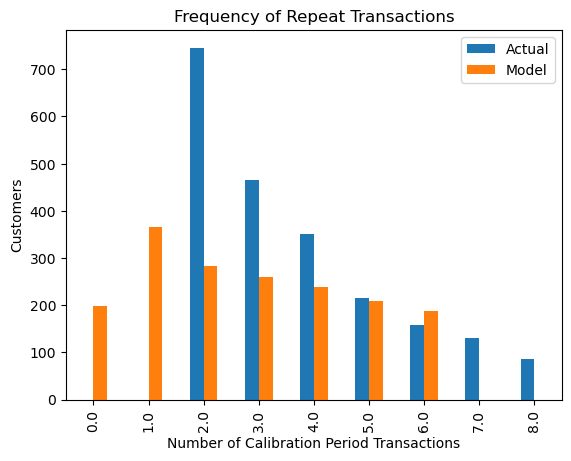

In [124]:
plot_period_transactions(bgf)

Analysis of the Plot
X-Axis (Number of Calibration Period Transactions):

This represents the number of transactions customers made during the calibration period (historical data used to fit the model).
Y-Axis (Customers):

This shows the number of customers who made a specific number of transactions.
Blue Bars (Actual):

These represent the actual number of customers who made a specific number of transactions during the calibration period.
Orange Bars (Model):

These represent the model's predictions of how many customers were expected to make that specific number of transactions.

In [129]:
(bgf.conditional_expected_number_of_purchases_up_to_time(1,df_uk['Frequency'],df_uk['Recency'],df_uk['T']).sort_values(ascending=False).head(10)).astype(int)

Customer ID
12748.0    3
17841.0    1
13089.0    1
14606.0    1
15311.0    1
12971.0    1
13408.0    0
18102.0    0
13798.0    0
14527.0    0
dtype: int32

Expected Purchases for the next 6 months using a BG/NBD (Beta-Geometric/Negative Binomial Distribution) model

In [135]:
df_uk['exp_purch_6_months'] = bgf.predict(4*6,df_uk['Frequency'],df_uk['Recency'],df_uk['T'])

In [140]:
(df_uk.sort_values(by='exp_purch_6_months',ascending=False)).round(2).head()

,Monetary,Recency,T,Frequency,exp_purch_6_months
Customer ID,,,,,
12748.0,154.56,53,53,209,75.13
17841.0,328.82,53,53,124,44.88
13089.0,605.19,52,52,97,35.81
14606.0,129.96,53,53,93,33.85
15311.0,667.60,53,53,91,33.14


The Gamma-Gamma model is a probabilistic model used to estimate the monetary value of a customer (how much a customer is expected to spend on average). It works alongside models like BG/NBD (Beta-Geometric/Negative Binomial Distribution) to predict the frequency of purchases and monetary value.

In [150]:
ggf=GammaGammaFitter(penalizer_coef=0.01)

In [153]:
ggf.fit(df_uk['Frequency'],df_uk['Monetary'])

<lifetimes.GammaGammaFitter: fitted with 2570 subjects, p: 3.82, q: 0.35, v: 3.75>

In [155]:
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.815299,0.102158,3.615070,4.015528
q,0.347823,0.007772,0.332591,0.363056
v,3.749347,0.102765,3.547927,3.950767


ggf.conditional_expected_average_profit(...):

This method from the Gamma-Gamma model calculates the expected average profit (or monetary value) for each customer, given their frequency (how often they make purchases) and monetary (how much they spend per transaction).
The conditional part means that the expected profit is calculated based on the customer's past behavior (frequency and spending).

In [174]:
df_uk['exp_average_profit']=(ggf.conditional_expected_average_profit(df_uk['Frequency'],df_uk['Monetary'])).round(2)
df_uk

,Monetary,Recency,T,Frequency,exp_purch_6_months,exp_average_profit
Customer ID,,,,,,
12747.0,381.46,52,52,11,4.752448,387.83
12748.0,154.56,53,53,209,75.126555,154.70
12749.0,814.49,29,30,5,3.885227,844.10
12820.0,235.58,46,46,4,2.455371,247.08
12822.0,474.44,2,12,2,2.979529,520.83
...,...,...,...,...,...,...
18272.0,513.10,34,35,6,3.967638,528.79
18273.0,68.00,36,36,3,2.478188,73.43
18282.0,89.02,16,18,2,3.129171,99.39



<!-- Customer Lifetime Value (CLTV) is the total revenue a business expects to earn from a customer over their entire relationship.

It is calculated using:

BG/NBD Model → Predicts how many future purchases a customer will make.
Gamma-Gamma Model → Estimates how much the customer will spend per transaction.

Formula (Simplified):
cltv = Predicted Transactions × Expected Spend per Transaction
CLTV=Predicted Transactions×Expected Spend per Transaction

Customer Lifetime Value (CLTV) for each customer over the next 6 weeks based on their past purchasing frequency, recency, total observation time, and average monetary value, using the Gamma-Gamma and Beta-Geometric models. -->



In [176]:
# CLV calculation (monetary value) using GammaGammaFitter
cltv= ggf.customer_lifetime_value(bgf,df_uk['Frequency'],df_uk['Recency'],df_uk['T'],df_uk['Monetary'],time=6,freq='W')


In [183]:
cltv

,Customer ID,clv
0,12747.0,1929.077230
1,12748.0,12158.927648
2,12749.0,3430.341569
3,12820.0,635.067518
4,12822.0,1621.532908
...,...,...
2565,18272.0,2194.936007
2566,18273.0,190.452972
2567,18282.0,325.177508
2568,18283.0,964.204169


why Use reset_index()?
If you need to merge cltv with another DataFrame, like df_uk.
If you want to export the data as a CSV or Excel file.
To make filtering easier, since some operations require columns rather than an index.
Before using reset_index(), cltv was a Series where Customer ID was the index.
reset_index() converts cltv into a DataFrame with Customer ID as a regular column, making it easier to merge or manipulate in subsequent steps.

In [186]:
cltv=cltv.reset_index()

on='Customer ID': Merges the DataFrames based on the Customer ID column, which must exist in both df_uk and cltv.
how='left': A left join means all rows from df_uk will be retained, and the matching Customer ID values from cltv will be added. If a Customer ID in df_uk doesn't have a match in cltv, the result will have NaN for that customer’s CLTV.
The cltv_final DataFrame will contain all the columns from df_uk and the corresponding CLTV values from cltv for each Customer ID.

In [190]:
cltv_final=df_uk.merge(cltv,on='Customer ID', how='left')

In [195]:
cltv_final=cltv_final.sort_values(by='clv',ascending= False).head()

scaler = MinMaxScaler(feature_range=(0, 1)) is a function from scikit-learn used to normalize or scale data to a specific range, usually between 0 and 1.

Explanation:
MinMaxScaler: It transforms features (columns) by scaling them so that the values are within the specified range (default is 0 to 1).
feature_range=(0, 1): This sets the desired range for the transformed data. The original values will be scaled such that the minimum value becomes 0 and the maximum value becomes 1.

In [203]:
scaler=MinMaxScaler(feature_range=(0,1))

scaler.fit(): This step computes the min and max values from the column(s) of the data that are passed to it. It then uses these values to learn how to scale the data between 0 and 1 (or whatever range you specify in feature_range).
cltv_final[['clv']]: This selects the clv column from the cltv_final DataFrame, which represents the Customer Lifetime Value that you want to scale.
Why are we doing this step?
We perform this step to prepare the clv data for scaling so that it fits within the specified range (0 to 1). This is important because:

Normalization ensures that the clv values are on the same scale, which can improve the performance of machine learning models and algorithms, especially those sensitive to differences in magnitude (e.g., neural networks, k-means clustering).

In [ ]:

# In machine learning, particularly when using scaling or normalization, fit and transform are two separate operations that serve different purposes. Here’s a breakdown:

# 1. fit():
# Purpose: The fit() method learns the parameters (like the minimum and maximum values, or the mean and standard deviation) from the data that you are passing to it.
# For scaling with MinMaxScaler, fit() computes:
# The minimum and maximum values of the data.
# In summary: fit() learns the statistical properties of the data.
# 2. transform():
# Purpose: The transform() method applies the learned parameters (from fit()) to the data to scale or normalize it.
# For scaling with MinMaxScaler, transform() scales the data to a new range (e.g., 0 to 1) based on the min and max values learned from fit().
# In summary: transform() scales or adjusts the data using the parameters learned in fit().
# Why do we use both?
# fit() is necessary to learn the scaling parameters (like the minimum and maximum).
# transform() is necessary to apply the scaling to the actual data, so the data is normalized or standardized.

In [208]:
scaler.fit(cltv_final[['clv']])

MinMaxScaler()

In [210]:
#Transform 
cltv_final['scaled_cltv']=scaler.transform(cltv_final[['clv']])

In [218]:
cltv_final.sort_values(by='scaled_cltv',ascending=False).head()


,Customer ID,Monetary,Recency,T,Frequency,exp_purch_6_months,exp_average_profit,index,clv,scaled_cltv
2486,18102.0,3584.89,52,52,60,22.445362,3595.20,2486,84425.412248,1.000000
589,14096.0,3159.08,13,14,17,16.221510,3191.39,589,54041.806788,0.492497
2184,17450.0,2629.53,51,52,46,17.286350,2639.42,2184,47736.627535,0.387181
2213,17511.0,2921.95,52,53,31,11.735351,2938.27,2213,36080.571041,0.192488
1804,16684.0,2120.05,50,51,28,11.001951,2133.21,1804,24556.534123,0.000000


In [220]:
cltv_final.sort_values(by='scaled_cltv',ascending=False).tail()

,Customer ID,Monetary,Recency,T,Frequency,exp_purch_6_months,exp_average_profit,index,clv,scaled_cltv
2486,18102.0,3584.89,52,52,60,22.445362,3595.20,2486,84425.412248,1.000000
589,14096.0,3159.08,13,14,17,16.221510,3191.39,589,54041.806788,0.492497
2184,17450.0,2629.53,51,52,46,17.286350,2639.42,2184,47736.627535,0.387181
2213,17511.0,2921.95,52,53,31,11.735351,2938.27,2213,36080.571041,0.192488
1804,16684.0,2120.05,50,51,28,11.001951,2133.21,1804,24556.534123,0.000000
